# Pandas

Knihovna pro práci se daty pomocí konceptu strukturované tabulky. 


### Vlastnosti:
- Základem dvourozměrná tabulka. Typicky sloupce jsou pojmenované veličiny, řádky jsou indexy údajů.
- Snadný výběr, třídění a reorganizace tabulek.
- Interakce s úložišti dat: CSV, JSON, Excel, databáze
- Rychlá vizualizace.
- Vazba na statistické nástroje.

### Alternativy
- [Polars](https://pola.rs/) novější, lepší syntaxe, rychlejší; zatím méně rozšířené
- [Dask](https://www.dask.org/) large datasets, large arrays, parallel computing
- [PySparks](https://duckdb.org/) similar to Dask (Apache)

Zdroj: [Exploring Data in Jupyter with Python and Pandas](https://hex.tech/blog/explore-data-with-python-and-pandas/)

In [28]:
# POZOR: Nutno instalovat moduly:'xlwt', 'xlrd'
# Pro Excel export, import.

import matplotlib.pyplot as plt
import pandas as pd 

# statické grafy 
%matplotlib inline



## DataFrame

- Základní datová struktura v Pandas, je `DataFrame` - dvourozměrná tabulka.
- Pojmonované sloupce (veličiny)
- číslované řádky (nebo index), např. jednotlivá pozorování
- vícerozměrné tabulky je vždy možno převést na dvou rozměrnou

## Čtení datasetu
Základní funkce pro čtení tabulky z CSV formátu, lez volit oddělovač, řádek hlavičky, přeskakované řádky, kódování, ....

Načtenou tabulku nám Jupyter pěkně zobrazí, pokud ji dáme jako poslední řádek buňky. 

In [46]:
print(pd.__version__)
df = pd.read_csv('titanic.csv')
print(type(df))
print(type(df['Age']))

2.3.2
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [7]:
# Ruční vyvolání "pěkného zobrazení"
from IPython.display import display
display(df)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## Přehled datasetu

In [8]:
# jména sloupců a prvních pár řádků
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
# Podrobnější informace o sloupcích
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Základní (popisné) satistiky

In [10]:
# Vypíše základní statistiky pro numerické sloupce.
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Vidíme, že 'age' má menší počet hodnot. Může to být přítomností nedefinovaných hodnot:'NaN'. 
Vypišme si jakých hodnot tato veličina může nabývat. 

In [36]:
import numpy as np

np.sort(df['Age'].unique())

array([ 0.42,  0.67,  0.75,  0.83,  0.92,  1.  ,  2.  ,  3.  ,  4.  ,
        5.  ,  6.  ,  7.  ,  8.  ,  9.  , 10.  , 11.  , 12.  , 13.  ,
       14.  , 14.5 , 15.  , 16.  , 17.  , 18.  , 19.  , 20.  , 20.5 ,
       21.  , 22.  , 23.  , 23.5 , 24.  , 24.5 , 25.  , 26.  , 27.  ,
       28.  , 28.5 , 29.  , 30.  , 30.5 , 31.  , 32.  , 32.5 , 33.  ,
       34.  , 34.5 , 35.  , 36.  , 36.5 , 37.  , 38.  , 39.  , 40.  ,
       40.5 , 41.  , 42.  , 43.  , 44.  , 45.  , 45.5 , 46.  , 47.  ,
       48.  , 49.  , 50.  , 51.  , 52.  , 53.  , 54.  , 55.  , 55.5 ,
       56.  , 57.  , 58.  , 59.  , 60.  , 61.  , 62.  , 63.  , 64.  ,
       65.  , 66.  , 70.  , 70.5 , 71.  , 74.  , 80.  ,   nan])

## Indexování a podvýběry

Hranaté indexované řetězcem vybírají sloupce. 

In [ ]:
# Jeden index / název sloupce.
df['Fare']

Pro jména sloupců, která jsou platnými identifikátory lze použít také tečkovací notaci.

In [ ]:
df.Fare

Pomocí řezu (slice)  lze vybrat podmnožinu řádků (nekonzistentní!!). Podobně jako u listu, nebo array,

In [37]:
# I číselný label vybírá sloupec.
df[10:20]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
12,13,0,3,"Saundercock, Mr. William Henry",male,20.0,0,0,A/5. 2151,8.0500,NaN,S
13,14,0,3,"Andersson, Mr. Anders Johan",male,39.0,1,5,347082,31.2750,NaN,S
14,15,0,3,"Vestrom, Miss. Hulda Amanda Adolfina",female,14.0,0,0,350406,7.8542,NaN,S
15,16,1,2,"Hewlett, Mrs. (Mary D Kingcome)",female,55.0,0,0,248706,16.0000,NaN,S
16,17,0,3,"Rice, Master. Eugene",male,2.0,4,1,382652,29.1250,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
18,19,0,3,"Vander Planke, Mrs. Julius (Emelia Maria Vande...",female,31.0,1,0,345763,18.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C


[`.iloc[...]`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.iloc.html)
Obecný výběr v řádcích i sloupcích pomocí číselných indexů.

In [ ]:
# První dva řádky; sloupce 0 a 2
df.iloc[0:2, [0,2]]

[`.loc[...]`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.loc.html)
Obecný výběr pomocí názvů sloupců/řádků (label).

In [40]:

# První dva řádky; sloupce 0 a 2
df.loc[0:10,['Survived', 'Pclass']]

,Survived,Pclass
0,0,3
1,1,1
2,1,3
3,1,1
4,0,3
5,0,3
6,0,1
7,0,3
8,1,3
9,1,2


Pro přístup k řádkům lze nastavit libovolný sloupec nebo tuple sloupců jako index. Se v `.loc[]` použijí řetězce i pro řádky.

POZOR, všechny operace na DataFrame vytvářejí nový objekt a je třeba použít přiřazení. Modifikaci DataFrame a provedení operace na vstupním objektu lze pomocí parametru `, pokud není zadán parameter 'inplace=True'

In [50]:
# Repatability of the cell
#df.reset_index(inplace=True)

# Operace na data frame ho nemodifikují, pokud není zadán parameter 'inplace=True'
df2 = df.set_index(['Age', 'Pclass'])
print("Original df unchanged:")
display(df.head())

# 
#df = df.set_index('Name')
display(df2)
df2.loc[(22.0, 3)]

Original df unchanged:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


PassengerId  Survived  \
Age  Pclass                          
22.0 3                 1         0   
38.0 1                 2         1   
26.0 3                 3         1   
35.0 1                 4         1   
     3                 5         0   
...                  ...       ...   
27.0 2               887         0   
19.0 1               888         1   
NaN  3               889         0   
26.0 1               890         1   
32.0 3               891         0   

                                                          Name     Sex  SibSp  \
Age  Pclass                                                                     
22.0 3                                 Braund, Mr. Owen Harris    male      1   
38.0 1       Cumings, Mrs. John Bradley (Florence Briggs Th...  female      1   
26.0 3                                  Heikkinen, Miss. Laina  female      0   
35.0 1            Futrelle, Mrs. Jacques Heath (Lily May Peel)  female      1   
     3                                Allen, Mr. William Henry    male      0   
...                                                        ...     ...    ...   
27.0 2                                   Montvila, Rev. Juozas    male      0   
19.0 1                            Graham, Miss. Margaret Edith  female      0   
NaN  3                Johnston, Miss. Catherine Helen "Carrie"  female      1   
26.0 1                                   Behr, Mr. Karl Howell    male      0   
32.0 3                                     Dooley, Mr. Patrick    male      0   

             Parch            Ticket     Fare Cabin Embarked  
Age  Pclass                                                   
22.0 3           0         A/5 21171   7.2500   NaN        S  
38.0 1           0          PC 17599  71.2833   C85        C  
26.0 3           0  STON/O2. 3101282   7.9250   NaN        S  
35.0 1           0            113803  53.1000  C123        S  
     3           0            373450   8.0500   NaN        S  
...            ...               ...      ...   ...      ...  
27.0 2           0            211536  13.0000   NaN        S  
19.0 1           0            112053  30.0000   B42        S  
NaN  3           2        W./C. 6607  23.4500   NaN        S  
26.0 1           0            111369  30.0000  C148        C  
32.0 3           0            370376   7.7500   NaN        Q  

[891 rows x 10 columns]

/tmp/ipykernel_184191/2049827886.py:12: PerformanceWarning: indexing past lexsort depth may impact performance.
  df2.loc[(22.0, 3)]


PassengerId  Survived                               Name     Sex  \
Age  Pclass                                                                     
22.0 3                 1         0            Braund, Mr. Owen Harris    male   
     3                61         0              Sirayanian, Mr. Orsen    male   
     3                81         0               Waelens, Mr. Achille    male   
     3               113         0             Barton, Mr. David John    male   
     3               142         1           Nysten, Miss. Anna Sofia  female   
     3               213         0             Perkin, Mr. John Henry    male   
     3               226         0       Berglund, Mr. Karl Ivar Sven    male   
     3               244         0      Maenpaa, Mr. Matti Alexanteri    male   
     3               288         0               Naidenoff, Mr. Penko    male   
     3               290         1               Connolly, Miss. Kate  female   
     3               321         0                 Dennis, Mr. Samuel    male   
     3               377         1    Landergren, Miss. Aurora Adelia  female   
     3               396         0                Johansson, Mr. Erik    male   
     3               475         0        Strandberg, Miss. Ida Sofia  female   
     3               479         0          Karlsson, Mr. Nils August    male   
     3               522         0                    Vovk, Mr. Janko    male   
     3               554         1  Leeni, Mr. Fahim ("Philip Zenni")    male   
     3               555         1                 Ohman, Miss. Velin  female   
     3               589         0              Gilinski, Mr. Eliezer    male   
     3               883         0       Dahlberg, Miss. Gerda Ulrika  female   

             SibSp  Parch             Ticket     Fare Cabin Embarked  
Age  Pclass                                                           
22.0 3           1      0          A/5 21171   7.2500   NaN        S  
     3           0      0               2669   7.2292   NaN        C  
     3           0      0             345767   9.0000   NaN        S  
     3           0      0             324669   8.0500   NaN        S  
     3           0      0             347081   7.7500   NaN        S  
     3           0      0          A/5 21174   7.2500   NaN        S  
     3           0      0            PP 4348   9.3500   NaN        S  
     3           0      0  STON/O 2. 3101275   7.1250   NaN        S  
     3           0      0             349206   7.8958   NaN        S  
     3           0      0             370373   7.7500   NaN        Q  
     3           0      0          A/5 21172   7.2500   NaN        S  
     3           0      0             C 7077   7.2500   NaN        S  
     3           0      0             350052   7.7958   NaN        S  
     3           0      0               7553   9.8375   NaN        S  
     3           0      0             350060   7.5208   NaN        S  
     3           0      0             349252   7.8958   NaN        S  
     3           0      0               2620   7.2250   NaN        C  
     3           0      0             347085   7.7750   NaN        S  
     3           0      0              14973   8.0500   NaN        S  
     3           0      0               7552  10.5167   NaN        S

Zmizel nám sloupec 'Name', ale přes jméno lze nyní indexovat řádky. 

Příklad multiindexu: tabulka předmětů STAGu, předmět identifikován pomocí dvojice (katedra, zkratka).

In [ ]:
# Error
# df['Name']

# přístup přes jméno
df.loc['Dooley, Mr. Patrick', :]

## Podmíněné podvýběry, filtry

Sploupce DF se chovají podobně jako jednorozměrná Nump Array. Zejména lze vybírat logickými poli/výrazy:

In [53]:
# Original dataframe unchanged.
np.sum(df.Age > 20)

np.int64(535)

In [55]:
# The inital set of baby names and bith rates
names = ['Bob','Jessica','Mary','John','Mel']
births = [968, 155, 77, 578, 973]
other = [0,1,2,3,4]

# We need lines of the table as tuples:
table = list(zip(names, births, other))
table

[('Bob', 968, 0),
 ('Jessica', 155, 1),
 ('Mary', 77, 2),
 ('John', 578, 3),
 ('Mel', 973, 4)]

In [56]:
# Create the data frame
df = pd.DataFrame(data = table, columns=['Names', 'Births', 0])
df

,Names,Births,0
0,Bob,968,0
1,Jessica,155,1
2,Mary,77,2
3,John,578,3
4,Mel,973,4


In [61]:
d = dict(zip(['Names', 'Births', 0], zip(*table)))
df1 = pd.DataFrame(d)
df1
df2 = df1

Libovolný sloupec lze použít jako index.

In [ ]:
df_by_names = df.set_index('Names')
#print(df_by_names)
from IPython.display import display
display(df_by_names)

### Otázka
**Jaký problém může být s výběrem pomocí názvů (labels)?**

In [60]:
# !! append již zrušen

df2 = df.append({'Names':'Bob', 'Births':10, 0:5}, ignore_index=True)
print(df2)
df2 = df2.set_index('Names')
print(df2)

# Podvýběr z tabulky, pro duplicitní jméno Bob
print(df2.loc['Bob', :])
df2.reset_index()


df2 = df.append({'Names':None, 'Births':11, 0:5}, ignore_index=True)

# doporučeno vytváření z listu dictů:
df.to_dict()
df2

AttributeError: 'DataFrame' object has no attribute 'append'

## IO operace
Klíčové pro práci s daty je jejich načtení a zápis z různých formátů. Vytvořená data zapíšeme a poté načteme.

In [76]:
# Write the dataframe into CSV file.
# Add column with line index.
# Write column header at the first row.
df2.set_index('Names', inplace=True)
df2.to_csv('births1880.csv', index=False)

# Other instance without index and header.
df2.to_csv('births_raw.csv', index=False, header=False)

In [69]:
import os
current_dir = os.getcwd()
print(current_dir)

# Reading with full path should not be necessary.
#path =  os.path.join(current_dir, 'births1880.csv')
#new_df = pd.read_csv(path)


#new_df = pd.read_csv('births_raw.csv', header=None, names=['A', 'B','C'])
new_df = pd.read_csv('births_raw.csv')
new_df


/mnt/exchange/pav/release/Section_3.1_Pandas


,Bob,968,0
0,Jessica,155,1
1,Mary,77,2
2,John,578,3
3,Mel,973,4


In [78]:
# Enable pretty display of Pandas tables


# Set own column names
new_df_full = pd.read_csv('births1880.csv', header=0,  index_col=0)
# Just text print, not so nice.
print(new_df_full)

# When no header, we have to tell it. Try both version.
#new_df = pd.read_csv('births_raw.csv')
new_df = pd.read_csv('births_raw.csv', header=None, names= ['name', 'freq', 'i'])

# Get nice table display.
from IPython.display import display
display(new_df)

        0
Births   
968     0
155     1
77      2
578     3
973     4


,name,freq,i
0,968,0,NaN
1,155,1,NaN
2,77,2,NaN
3,578,3,NaN
4,973,4,NaN


## Other IO functions

[Přehled](https://pandas.pydata.org/pandas-docs/stable/io.html) s oficiální dokumentace. 
Zejména formáty: 
- CSV - comma separate values, ale možné i jiné separátory, textový formát tabulky
- JSON - hierarchický formát, řeší escapování řeťezců, stále textový formát
- MS Excel - binární proprietární, velmi nevhodný pro práci s velkými daty, velmi vhodný pro interaktivní práci s malými daty, podpora pro různé verze Excel formátů
- HDF5 - otevřený binární formát navržený pro velká data
- SAS - nativní formát velmi používaného statistického balíku
- SQL - databáze


 

In [79]:
## Sorting

# Get first two names with highest frequency.
sorted_df = new_df.sort_values('freq', ascending=False)

# head() and tail() methods
display(sorted_df.head(5))

# Slices works as well.
display(sorted_df[:2])


,name,freq,i
4,973,4,NaN
3,578,3,NaN
2,77,2,NaN
1,155,1,NaN
0,968,0,NaN


,name,freq,i
4,973,4,NaN
3,578,3,NaN


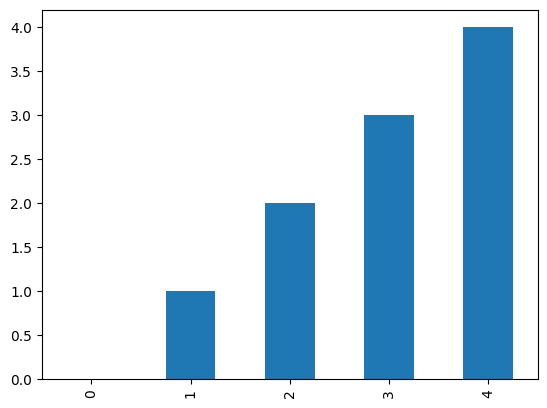

In [80]:
## Simple plotting

# See that we can index columns and rows by their names.
new_df['freq'].plot.bar()
plt.show()

In [ ]:
## Works better when we set names to rows by settign the row index.

name_df = new_df.set_index('name')
display(name_df)
name_df['freq'].plot.bar()
plt.show()

## More complex data processing example
First prepare a data frame with random data.

In [84]:
import numpy as np

# set seed
np.random.seed(111)

# Function to generate test data
def CreateDataSet(Number=1):
    
    Output = []
    
    for i in range(Number):
        
        # Create random dates.
        rng = pd.date_range(start='1/1/2009', end='12/31/2012', freq='D')        
        rng = np.random.choice(rng, 100)        
        
        # Create random data
        count = np.random.randint(low=25,high=1000,size=len(rng))
        
        # Mark pool
        mark = [0,1,2,3]
        
        # Make a random list of statuses
        random_mark = np.random.choice(np.array(mark), size = len(rng))
                        #[status[np.random.randint(low=0,high=len(status))] for i in range(len(rng))]
        
        # State pool
        states = ['GA','FL','fl','NY','NJ','TX']
        
        # Make a random list of states 
        random_states = np.random.choice(np.array(states), size = len(rng))
                        #[states[np.randint(low=0,high=len(states))] for i in range(len(rng))]
    
        Output.extend(zip(random_states, random_mark, count, rng))
        
    return Output



In [87]:
dataset = CreateDataSet(4)

r_df = pd.DataFrame(data=dataset, columns=['State','Mark','CustomerCount','StatusDate'])
r_df.info()
print("---")
r_df.head()
df = r_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   State          400 non-null    object        
 1   Mark           400 non-null    int64         
 2   CustomerCount  400 non-null    int64         
 3   StatusDate     400 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 12.6+ KB
---


## Excel IO

In [ ]:
 {PE_warnings} ~/workspace/flow123d$ sudo pip3 install xlwt
[sudo] password for jb: 
WARNING: The directory '/home/jb/.cache/pip/http' or its parent directory is not owned by the current user and the cache has been disabled. Please check the permissions and owner of that directory. If executing pip with sudo, you may want sudo's -H flag.
WARNING: The directory '/home/jb/.cache/pip' or its parent directory is not owned by the current user and caching wheels has been disabled. check the permissions and owner of that directory. If executing pip with sudo, you may want sudo's -H flag.
Collecting xlwt
  Downloading https://files.pythonhosted.org/packages/44/48/def306413b25c3d01753603b1a222a011b8621aed27cd7f89cbc27e6b0f4/xlwt-1.3.0-py2.py3-none-any.whl (99kB)
     |████████████████████████████████| 102kB 3.9MB/s 
Installing collected packages: xlwt
Successfully installed xlwt-1.3.0
WARNING: You are using pip version 19.3.1; however, version 20.0.2 is available.
You should consider upgrading via the 'pip install --upgrade pip' command.
 {PE_warnings} ~/workspace/flow123d$ ^C
 {PE_warnings} ~/workspace/flow123d$ 




In [ ]:
# POZOR: Nutno instalovat moduly:'xlwt', 'xlrd'

file_name = 'customer_reports.xlsx'
#r_df.to_excel(file_name, index=False)
#print('Data exported.')

# Parse a specific sheet 0
df = pd.read_excel(file_name)
#df.reset_index(inplace=True)

print("Colum types:")
print(df.dtypes)

df.head()

# TODO: show read from google calc


## Prepare data
This section attempts to clean up the data for analysis.

1. Make sure the state column is all in upper case
2. Only select records where the mark is valid: 1,2,3
3. Merge (NJ and NY) to NY in the state column
4. Remove any outliers (any odd results in the data set)


In [88]:
# See what states we have.... Of course 'fl' should be 'FL'.
df['State'].unique()

array([np.str_('GA'), np.str_('TX'), np.str_('NJ'), np.str_('NY'),
       np.str_('fl'), np.str_('FL')], dtype=object)

In [89]:
# Clean State Column, convert to upper case
def to_upper(x):
    return x.upper()

df['State'] = df['State'].apply(to_upper)
print(df['State'].unique())
df.head()

['GA' 'TX' 'NJ' 'NY' 'FL']


,State,Mark,CustomerCount,StatusDate
0,GA,1,768,2009-06-20
1,TX,0,313,2012-04-04
2,NJ,0,218,2009-01-06
3,NY,0,38,2010-09-22
4,NJ,3,747,2012-10-01


In [90]:
df['Mark'].unique()

array([1, 0, 3, 2])

In [91]:
df['Mark']
df['Mark'] > 0
df[df['Mark'] > 0]

,State,Mark,CustomerCount,StatusDate
0,GA,1,768,2009-06-20
4,NJ,3,747,2012-10-01
5,NJ,1,457,2011-04-01
6,FL,3,543,2011-10-24
7,TX,1,373,2012-03-16
...,...,...,...,...
394,GA,3,746,2012-08-11
395,GA,3,268,2011-06-08
396,FL,3,297,2012-08-24
397,TX,2,184,2011-12-10


In [92]:
# Only grab where Mark in [1,2,3]
mask = df['Mark'] in [0,2,3]    # Error since 'in' has ambiguous operands.


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [94]:
# Only grab where Mark in [1,2,3]
#display(df.head())
#df.set_index('StatusDate')['Mark']
mask = df['Mark'].isin([0,2,3])
#mask
df1 = df[mask]
df1.head()

,State,Mark,CustomerCount,StatusDate
1,TX,0,313,2012-04-04
2,NJ,0,218,2009-01-06
3,NY,0,38,2010-09-22
4,NJ,3,747,2012-10-01
6,FL,3,543,2011-10-24


In [95]:
# Convert NJ to NY
mask = df1.State == 'NJ'

# This produce a warnning as there is chained indexing.
#df1['State'][mask] = 'NY'

# This should be correct equivalent.
df1.loc[mask, 'State'] = 'NY'



df1['State'].unique()

array(['TX', 'NY', 'FL', 'GA'], dtype=object)

StatusDate
2009-01-02    354
2009-01-06    218
2009-01-06    592
2009-01-22    815
2009-01-25    894
             ... 
2012-12-22    726
2012-12-23    218
2012-12-23    772
2012-12-27    527
2012-12-30    770
Name: CustomerCount, Length: 400, dtype: int64

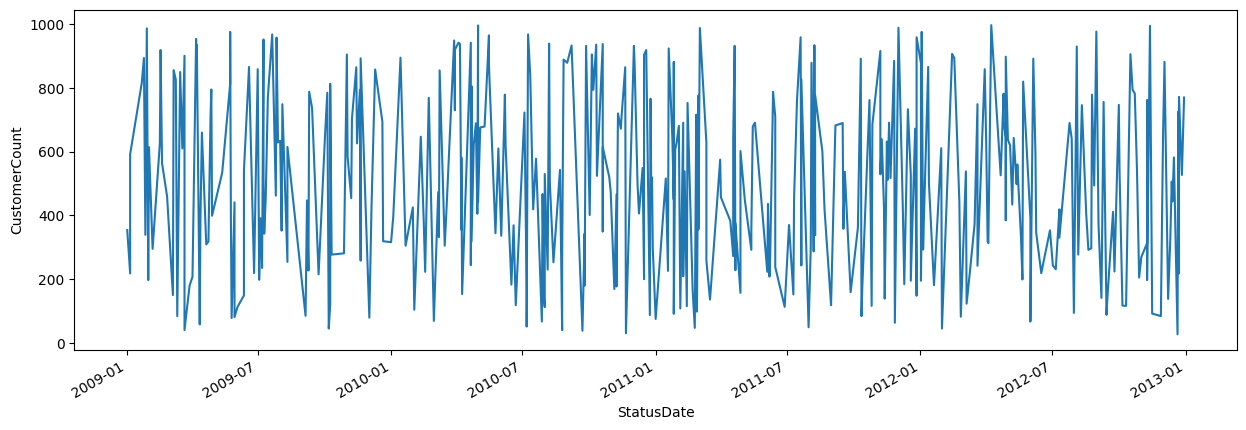

In [103]:
df.reset_index(inplace=True)
df.set_index('StatusDate', inplace=True)
df.sort_values('StatusDate', inplace=True)
count = df['CustomerCount']
display(count)
count.plot(figsize=(15,5), ylabel=count.name);

#plt.show()

In [113]:
# Reset index, to have StatusDate as regular column.
df_a = df.reset_index()
print(df_a.head())
#display(df_a.head())

# Group by State and StatusDate, sum rows with same index.
#display(df_a.groupby(['State']))
Daily = df_a.groupby(['State']).mean()
print('grouped Daily')
display(Daily)
Daily['Mark'].unique()



  StatusDate  index State  Mark  CustomerCount
0 2009-01-02    166    NY     3            354
1 2009-01-06      2    NJ     0            218
2 2009-01-06     58    GA     0            592
3 2009-01-22    169    GA     1            815
4 2009-01-25     13    NJ     1            894
grouped Daily


,StatusDate,index,Mark,CustomerCount
State,,,,
FL,2011-01-08 03:54:40.000000000,185.859259,1.592593,503.148148
GA,2010-09-14 15:14:35.675675648,195.743243,1.689189,528.581081
NJ,2011-04-13 00:00:00.000000000,192.433333,1.500000,467.950000
NY,2010-12-21 01:22:17.142857216,217.157143,1.600000,493.500000
TX,2011-04-05 02:21:38.360655616,220.934426,1.557377,538.196721


array([1.59259259, 1.68918919, 1.5       , 1.6       , 1.55737705])

In [116]:
# Group by State and StatusDat, use both max ans um aggregation
#display(df_a)
        
Daily = df_a.groupby(['State', 'StatusDate']).agg([np.sum, np.max])
display(Daily.head())

# Group by State and StatusDat, use max for Status, sum for Count
Daily = df_a.groupby(['State','StatusDate']) \
        .agg({'Mark':np.max, 'CustomerCount':np.sum})
display(Daily.head())


/tmp/ipykernel_184191/620962331.py:4: FutureWarning: The provided callable <function sum at 0x77b295803c40> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  Daily = df_a.groupby(['State', 'StatusDate']).agg([np.sum, np.max])
/tmp/ipykernel_184191/620962331.py:4: FutureWarning: The provided callable <function max at 0x77b295828680> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  Daily = df_a.groupby(['State', 'StatusDate']).agg([np.sum, np.max])
/tmp/ipykernel_184191/620962331.py:4: FutureWarning: The provided callable <function sum at 0x77b295803c40> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  Daily = df_a.groupby(['S

index      Mark     CustomerCount     
                   sum  max  sum max           sum  max
State StatusDate                                       
FL    2009-02-01   363  363    1   1           614  614
      2009-02-19   168  168    0   0           564  564
      2009-03-06    89   89    1   1           150  150
      2009-04-02    97   97    1   1           207  207
      2009-04-07   240  240    3   3           954  954

/tmp/ipykernel_184191/620962331.py:9: FutureWarning: The provided callable <function max at 0x77b295828680> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  .agg({'Mark':np.max, 'CustomerCount':np.sum})
/tmp/ipykernel_184191/620962331.py:9: FutureWarning: The provided callable <function sum at 0x77b295803c40> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'Mark':np.max, 'CustomerCount':np.sum})


Mark  CustomerCount
State StatusDate                     
FL    2009-02-01     1            614
      2009-02-19     0            564
      2009-03-06     1            150
      2009-04-02     1            207
      2009-04-07     3            954

In [ ]:
# Removing outliers 

# 1. create a mask
import numpy as np
import scipy.stats as st

st.zscore(df.CustomerCount)
mask = np.abs(st.zscore(df.CustomerCount)) < 1.5
np.sum(mask)

# unfortunately no standard function for IQR method
# use np.percentile
Q1, Q3 = np.percentile(df.CustomerCount , [25,75])
# ...

#2. extract masked
df[mask].boxplot(column='CustomerCount', by='State')

In [ ]:
# original DF boxplots
df.boxplot(column='CustomerCount', by='State')

In [ ]:
Daily.loc['FL'].plot()
Daily.loc['GA'].plot()
Daily.loc['NY'].plot()
Daily.loc['TX'].plot();
plt.show()


# Seaborn - high level statistical plotting

In [ ]:
import pandas as pd

# Dataset:
a = pd.DataFrame({ 'group' : np.repeat('A',500), 'value': np.random.normal(10, 5, 500), 'count': 500 })
b = pd.DataFrame({ 'group' : np.repeat('B',500), 'value': np.random.normal(13, 1.2, 500), 'count': 500 })
c = pd.DataFrame({ 'group' : np.repeat('B',500), 'value': np.random.normal(18, 1.2, 500), 'count': 500 })
d = pd.DataFrame({ 'group' : np.repeat('C',20), 'value': np.random.normal(25, 4, 20), 'count': 20 })
e = pd.DataFrame({ 'group' : np.repeat('D',100), 'value': np.random.uniform(12, size=100), 'count': 100 })
df=a.append(b).append(c).append(d).append(e)
df['size'] = df['count'] / 25 
display(df.head())

# Pandas boxplot
#dfs = df.set_index('State')
#display(dfs)
df.boxplot(column='value', by='group')


In [ ]:
# libraries and data
import seaborn as sns

 

# Seaborn Usual boxplot
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(111)
sns.boxplot(data=df, x='group', y='value')
plt.show()

# Box plot with jitter.
# outlier detection 
ax = sns.boxplot(x='group', y='value', data=df)
ax = sns.stripplot(x=df['group'], y='value', data=df, color="orange", jitter=0.2, size=2.5)
plt.title("Boxplot with jitter", loc="left")
plt.show()

# Violin plot.
sns.violinplot( x='group', y='value', data=df)
plt.title("Violin plot", loc="left")
plt.show()

# Excercise with diamonds
Pro následující operace vytvářejte pokud možno nové dataframy, ponechte vstupní DF v původním stavu.

- pro každý soupec určete datový typ
- pro sloupce typu 'str' určete množinu hodnot
- vytvořte dataframe s vymazanými řádky s barvou 'G'
- setřiďte dataframe sestupně podle ceny
- vypište diamanty se všemi rozměry >5
- vytvořte tabulku s 'cut' v řádcích a 'clarity' ve sloupcích, pro každou kombinaci (skupinu)
  vypočtěte počet diamantů ve skupině a medián jejich ceny
- pro každý datový sloupec vytvořte box plot s vyznačenými odlehlými pozorováními (outliers)
- odstraňte odlehlá pozorování (zejména: table, x, y, z)
- zobrazte a následně odstraňte duplicitní řádky


In [117]:
# Get the diamonds dataset
import pandas as pd
diamonds = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv')
print(diamonds)

       carat        cut color clarity  depth  table  price     x     y     z
0       0.23      Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1       0.21    Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2       0.23       Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3       0.29    Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4       0.31       Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75
...      ...        ...   ...     ...    ...    ...    ...   ...   ...   ...
53935   0.72      Ideal     D     SI1   60.8   57.0   2757  5.75  5.76  3.50
53936   0.72       Good     D     SI1   63.1   55.0   2757  5.69  5.75  3.61
53937   0.70  Very Good     D     SI1   62.8   60.0   2757  5.66  5.68  3.56
53938   0.86    Premium     H     SI2   61.0   58.0   2757  6.15  6.12  3.74
53939   0.75      Ideal     D     SI2   62.2   55.0   2757  5.83  5.87  3.64

[53940 rows x 10 columns]
